# Tugas 7: Geospatial Data Mining

### **Ketentuan:**

1. Dokumen *template* lab dengan format .ipynb dan dataset (jika dibutuhkan) telah disediakan di SCeLe
2. Jalankan kode pada dokumen .ipynb dan perhatikan dengan saksama apa yang potongan kode tersebut lakukan beserta dengan keluarannya. Jawablah pertanyaan yang disisipkan pada potongan program yang diberikan.
3. Dokumen Jupyter Notebook yang telah dilengkapi dengan jawaban dikumpulkan dengan format penamaan Kelas_LabX_NPM_Nama.ipynb. Contoh: A_Lab7_19064388342_TimothyOrvinEdwardo.ipynb
4. Kumpulkan dokumen tersebut pada submisi yang telah disediakan di SCeLe sebelum tenggat waktu yang ditentukan. Keterlambatan pengumpulan akan dikenakan penalti sebanyak satu poin per menit.
5. Lab ini dirancang sebagai tugas mandiri. Plagiarisme tidak diperkenankan dalam bentuk apapun. Adapun kolaborasi berupa diskusi (tanpa menyalin maupun mengambil jawaban orang lain) dan literasi masih diperbolehkan dengan mencantumkan kolaborator dan sumber.

### **Pengantar:**

1. Anda perlu mengunduh library terkait pengolahan data geospatial, seperti: geopandas, shapely, geopy untuk pengerjaan tugas lab ini.
2. Dataset yang digunakan adalah: jakarta_simplified_topo.json, Data Lokasi Halte.xlsx, dan Jumlah Penduduk Jakarta 2023.xlsx.
3. jakarta_simplified_topo.json -> dataset yang berisi data koordinat **lat** dan **long** peta Jakarta (di luar Kepulauan Seribu) dan batas wilayah-nya.
4. Data Lokasi Halte.xlsx -> dataset yang berisi data halte yang sering dikunjungi. Kolom yang tersedia:

| Kolom       | Deskripsi |
|-------------|-----------|
| **Nama Halte** | Nama halte yang sering dikunjungi. |
| **Rute** | Nomor atau kode rute yang melayani halte terkait. |
| **Tipe** | Tipe halte, terdiri dari "halte" atau "bus stop". |
| **Lokasi** | Kota di mana halte berlokasi. |
| **Lat** | Latitude halte. |
| **Long** | Longitude halte. |
| **In** | Kolom dengan tipe data binary. Nilai 1 menandakan halte tersebut menjadi lokasi di mana pengguna sering masuk / tap in. |
| **Out** | Kolom dengan tipe data binary. Nilai 1 menandakan halte tersebut menjadi lokasi di mana pengguna sering keluar / tap out. |
| **Transit** | Kolom dengan tipe data binary. Nilai 1 menandakan halte tersebut menjadi lokasi di mana pengguna sering melakukan transit ke rute lain. |


5. Jumlah Penduduk Jakarta 2023.xlsx -> dataset yang berisi jumlah penduduk Jakarta pada tahun 2023 berdasarkan Kabupaten / Kota. Kolom yang tersedia:

| Kolom            | Deskripsi |
|------------------|-----------|
| **KabKota**      | Nama kota administrasi Jakarta. |
| **Jumlah Penduduk** | Jumlah penduduk per kota administrasi pada tahun 2023. |


6. Anda dipersilakan untuk memilih pewarnaan yang menarik dan intuitutif untuk setiap visualisasi yang Anda tampilkan.

# Load and Transform Geospatial Data

1a. Import library yang diperlukan dan load data lokasi halte. (2)

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np
from math import radians
from sklearn.metrics.pairwise import haversine_distances
from sklearn.cluster import AgglomerativeClustering

# Supaya plot terlihat lebih besar
plt.rcParams["figure.figsize"] = (10, 10)

# 1a. Load data lokasi halte dari file Excel
halte_df = pd.read_excel("Data Lokasi Halte.xlsx")
print("Data Halte:")
print(halte_df.head())




Data Halte:
          Nama Halte Rute   Tipe           Lokasi       Lat        Long  In  \
0             Blok M    1  Halte  Jakarta Selatan -6.243500  106.800900   1   
1                CSW    1  Halte  Jakarta Selatan -6.239874  106.798413   1   
2   Bundaran Senayan    1  Halte  Jakarta Selatan -6.227400  106.801500   1   
3  Gelora Bung Karno    1  Halte  Jakarta Selatan -6.224200  106.805700   1   
4   Polda Metro Jaya    1  Halte  Jakarta Selatan -6.221400  106.809800   0   

   Out  Transit  
0    1        1  
1    1        1  
2    1        1  
3    1        1  
4    1        0  


1b. Konversikan kolom Lat dan Long menjadi bentuk geometry dan buatlah format dataframe data lokasi halte menjadi geodataframe. (3)

Hint:
- Gunakan shapely - geometry
- Gunakan crs EPSG:4326 ketika menjadikan geodataframe.

In [2]:
# 1b. Konversi kolom Lat dan Long menjadi geometry dan buat GeoDataFrame
# Pastikan bahwa kolom 'Lat' dan 'Long' benar-benar ada dan dalam format numerik
geometry = [Point(xy) for xy in zip(halte_df['Long'], halte_df['Lat'])]
halte_gdf = gpd.GeoDataFrame(halte_df, geometry=geometry, crs="EPSG:4326")
print("\nGeoDataFrame Halte:")
print(halte_gdf.head())


GeoDataFrame Halte:
          Nama Halte Rute   Tipe           Lokasi       Lat        Long  In  \
0             Blok M    1  Halte  Jakarta Selatan -6.243500  106.800900   1   
1                CSW    1  Halte  Jakarta Selatan -6.239874  106.798413   1   
2   Bundaran Senayan    1  Halte  Jakarta Selatan -6.227400  106.801500   1   
3  Gelora Bung Karno    1  Halte  Jakarta Selatan -6.224200  106.805700   1   
4   Polda Metro Jaya    1  Halte  Jakarta Selatan -6.221400  106.809800   0   

   Out  Transit                    geometry  
0    1        1    POINT (106.8009 -6.2435)  
1    1        1  POINT (106.79841 -6.23987)  
2    1        1    POINT (106.8015 -6.2274)  
3    1        1    POINT (106.8057 -6.2242)  
4    1        0    POINT (106.8098 -6.2214)  


# Visualize Geospatial Data

2a. Load data provinsi Daerah Khusus Jakarta dan jumlah penduduk tahun 2023, kemudian visualisasikan peta berdasarkan jumlah penduduknya. (5)

In [3]:
halte_df

,Nama Halte,Rute,Tipe,Lokasi,Lat,Long,In,Out,Transit
0,Blok M,1,Halte,Jakarta Selatan,-6.243500,106.800900,1,1,1
1,CSW,1,Halte,Jakarta Selatan,-6.239874,106.798413,1,1,1
2,Bundaran Senayan,1,Halte,Jakarta Selatan,-6.227400,106.801500,1,1,1
3,Gelora Bung Karno,1,Halte,Jakarta Selatan,-6.224200,106.805700,1,1,1
4,Polda Metro Jaya,1,Halte,Jakarta Selatan,-6.221400,106.809800,0,1,0
...,...,...,...,...,...,...,...,...,...
94,RS PIK 1,1A,Bus Stop,Jakarta Utara,-6.112105,106.752909,0,1,0
95,Semanggi,9,Halte,Jakarta Selatan,-6.221004,106.813613,1,1,0
96,Jalan Puri Harum,3E,Bus Stop,Jakarta Barat,-6.187170,106.738096,0,1,0
97,Jembatan Baru,3,Halte,Jakarta Barat,-6.154632,106.730475,0,0,1


In [4]:
# Load data peta Jakarta (file JSON) dan data jumlah penduduk (file Excel)
jakarta_map = gpd.read_file("jakarta-simplified-topo.json")


jakarta_map

,id,provinsi,kabkot,geometry
0,31-71,Jakarta,Jakarta Selatan,"POLYGON ((106.84903 -6.20757, 106.85756 -6.212..."
1,31-72,Jakarta,Jakarta Timur,"POLYGON ((106.97189 -6.15463, 106.97096 -6.162..."
2,31-73,Jakarta,Jakarta Pusat,"POLYGON ((106.87879 -6.16647, 106.87611 -6.175..."
3,31-74,Jakarta,Jakarta Barat,"POLYGON ((106.82131 -6.13683, 106.82631 -6.147..."
4,31-75,Jakarta,Jakarta Utara,"POLYGON ((106.97189 -6.15463, 106.96289 -6.156..."


In [5]:
pop_df = pd.read_csv("Jumlah Penduduk Jakarta 2023.csv", sep = ";")
pop_df

,KabKota,Jumlah Penduduk
0,Jakarta Selatan,2235606
1,Jakarta Timur,3079618
2,Jakarta Pusat,1049314
3,Jakarta Barat,2470054
4,Jakarta Utara,1808985


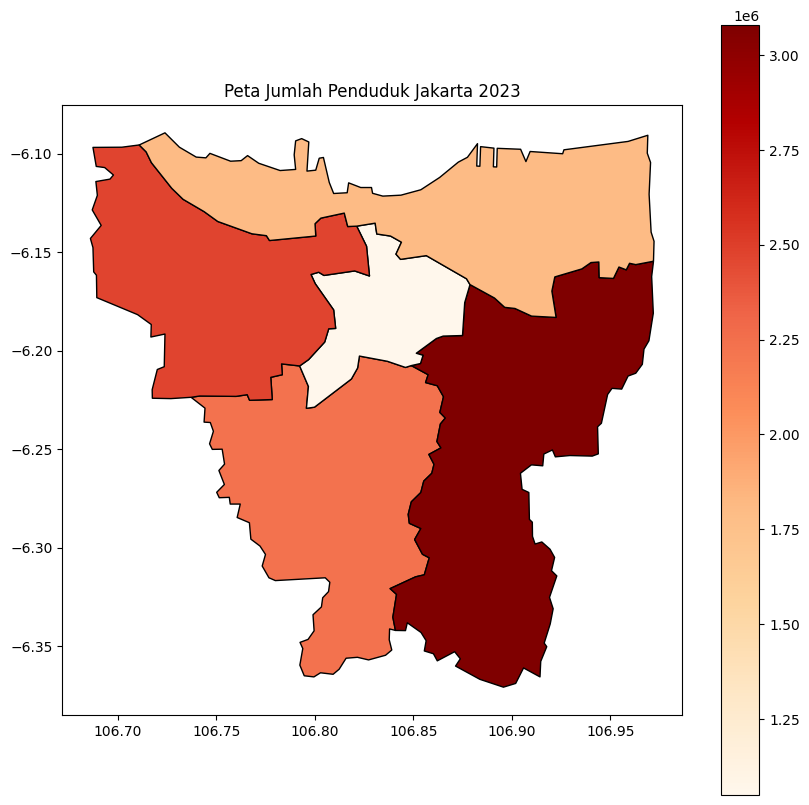

In [7]:
# Merge jakarta_map dengan pop_df:
jakarta_map = jakarta_map.merge(pop_df, left_on="kabkot", right_on="KabKota", how="left")

# Visualisasikan peta dengan choropleth berdasarkan jumlah penduduk
fig, ax = plt.subplots()
jakarta_map.plot(column='Jumlah Penduduk', ax=ax, legend=True, cmap='OrRd', edgecolor='black')
ax.set_title("Peta Jumlah Penduduk Jakarta 2023")
plt.show()

2b. Load data point lokasi halte, kemudian visualisasikan point (titik halte) bersamaan dengan peta Daerah Khusus Jakarta yang telah Anda load sebelumnya. (5)

Hint: lakukan overlay antara data peta Jakarta dengan titik lokasi halte.

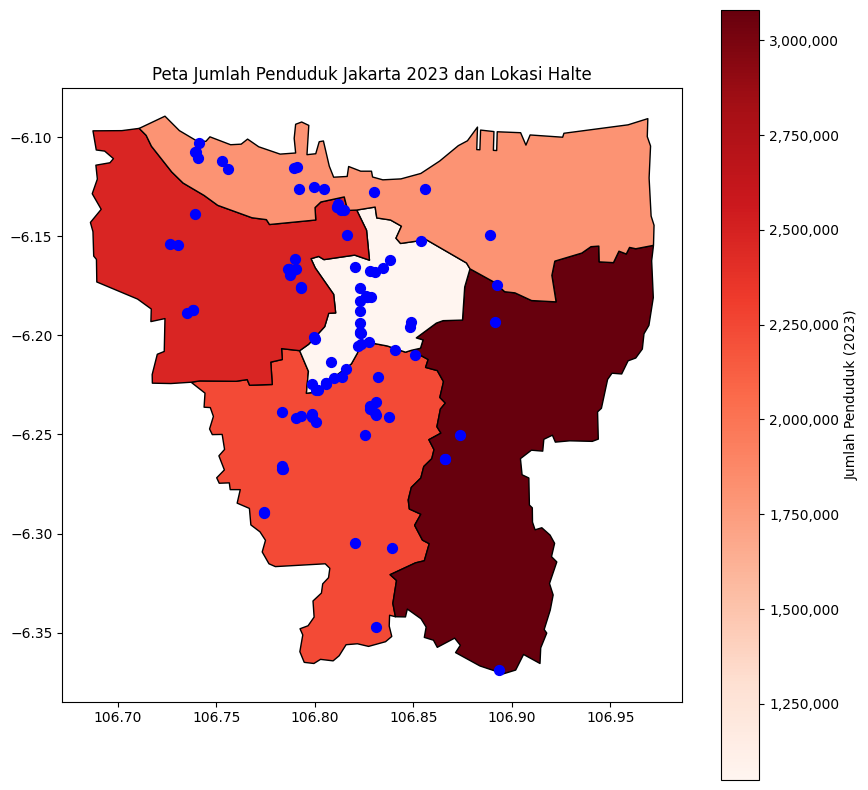

In [9]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Plot peta choropleth jumlah penduduk dengan colormap "Reds"
mappable = jakarta_map.plot(column='Jumlah Penduduk', 
                            ax=ax, 
                            legend=True, 
                            cmap='Reds', 
                            missing_kwds={"color": "lightgrey"}, 
                            edgecolor='black',
                            legend_kwds={
                                "label": "Jumlah Penduduk (2023)",
                                "orientation": "vertical"
                            })

# Overlay data lokasi halte
halte_gdf.plot(ax=ax, marker='o', color='blue', markersize=50)

# Atur formatter pada colorbar agar angka tampil penuh tanpa notasi ilmiah
cbar = mappable.get_figure().axes[-1]
cbar.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax.set_title("Peta Jumlah Penduduk Jakarta 2023 dan Lokasi Halte")
plt.show()




# Analyze Geospatial Data

3a. Sebuah minimarket ingin membuka gerai dan menargetkan pengguna Transjakarta. Salah satu penelitian yang pernah dilakukan adalah konsumen kerap berbelanja saat berada pada tujuan, sehingga tidak banyak membawa barang bawaan ke bus. Tunjukan lokasi **halte** yang menjadi target gerai tersebut akan dibuka. Visualisasikan dalam bentuk tabel dan peta. (10)

In [10]:
# Filter data untuk target halte: hanya yang berjenis "halte" dan dengan nilai Out == 1
target_halte = halte_gdf[(halte_gdf['Tipe'].str.lower() == 'halte') & (halte_gdf['Out'] == 1)]
print("Target Halte untuk Minimarket:")
target_halte[['Nama Halte', 'Rute', 'Tipe', 'Lokasi']]

Target Halte untuk Minimarket:


,Nama Halte,Rute,Tipe,Lokasi
0,Blok M,1,Halte,Jakarta Selatan
1,CSW,1,Halte,Jakarta Selatan
2,Bundaran Senayan,1,Halte,Jakarta Selatan
3,Gelora Bung Karno,1,Halte,Jakarta Selatan
4,Polda Metro Jaya,1,Halte,Jakarta Selatan
6,Tosari,1,Halte,Jakarta Pusat
7,Bundaran HI,1,Halte,Jakarta Pusat
8,MH Thamrin,1,Halte,Jakarta Pusat
9,Monas,1,Halte,Jakarta Pusat
10,Harmoni,1,Halte,Jakarta Pusat


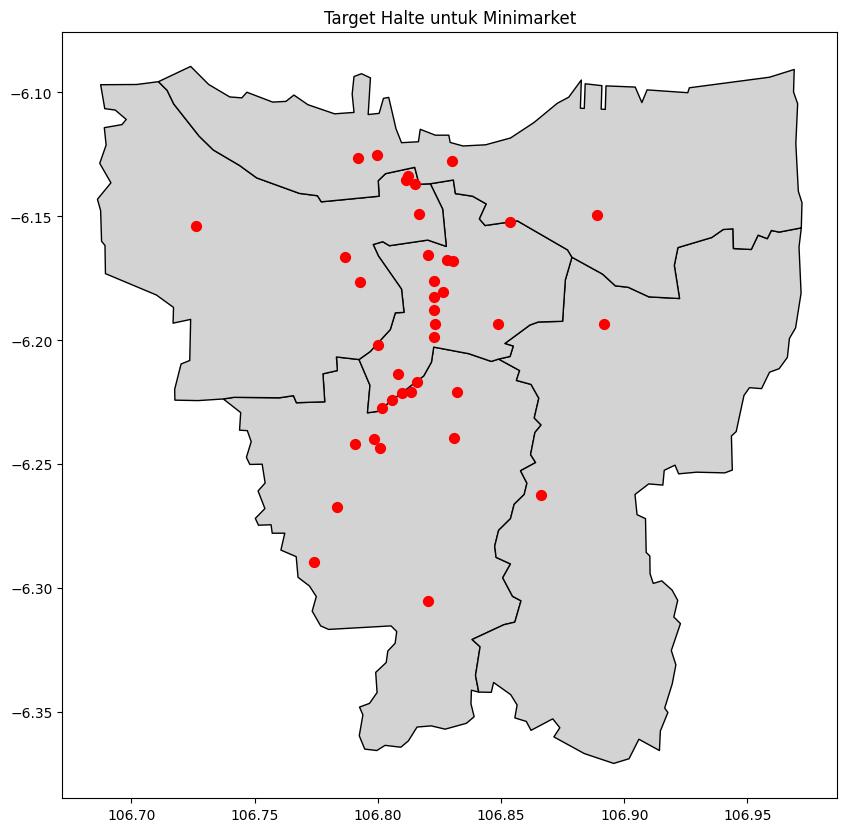

In [11]:
# Visualisasi target halte pada peta
fig, ax = plt.subplots()
jakarta_map.plot(ax=ax, color="lightgrey", edgecolor='black')
target_halte.plot(ax=ax, marker='o', color='red', markersize=50)
ax.set_title("Target Halte untuk Minimarket")
plt.show()

3b. Dari soal 3a, minimarket tersebut ingin membuka gerai yang radius nya maksimal 500 meter dari halte. Tunjukan wilayah atau zona sekitar halte yang memenuhi syarat tersebut. Visualisasikan dalam bentuk peta. (10)

Hint:
- Gunakan fungsi buffer dari geopandas.
- 500 meter dalam format EPSG:4326 = 0.0045

C:\Users\moham\AppData\Local\Temp\ipykernel_35848\518059551.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_halte['buffer'] = target_halte.geometry.buffer(0.0045)
C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


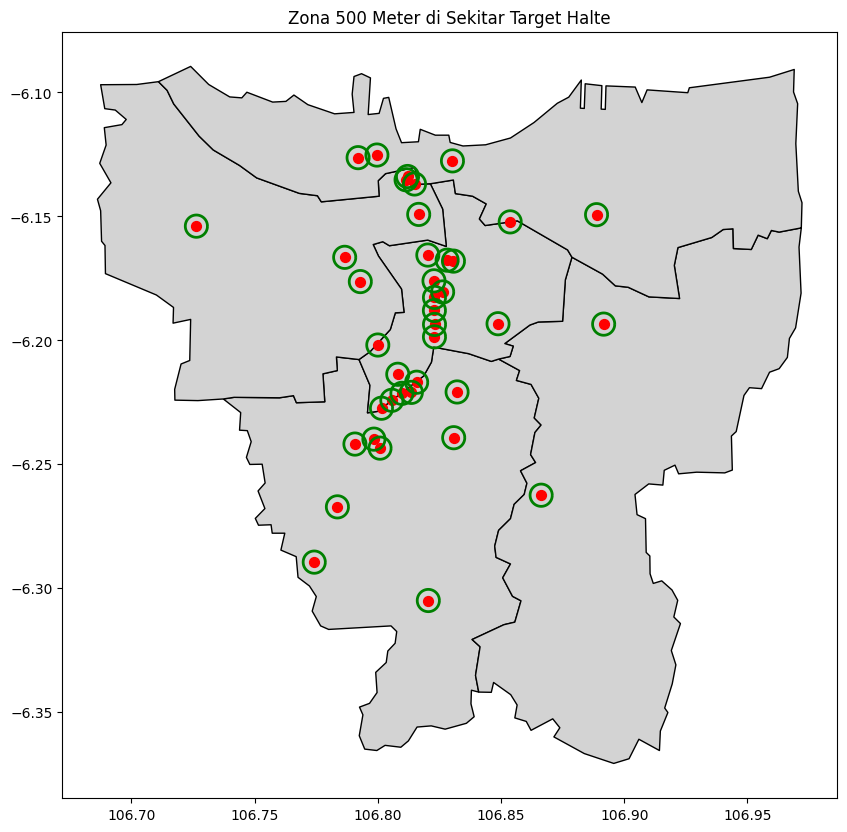

In [12]:
# Buat buffer 500 meter di sekitar target halte
target_halte['buffer'] = target_halte.geometry.buffer(0.0045)
buffer_gdf = gpd.GeoDataFrame(target_halte, geometry='buffer', crs="EPSG:4326")

# Visualisasikan peta dengan titik halte dan zona buffer
fig, ax = plt.subplots()
jakarta_map.plot(ax=ax, color="lightgrey", edgecolor='black')
target_halte.plot(ax=ax, marker='o', color='red', markersize=50)
buffer_gdf.boundary.plot(ax=ax, color='green', linewidth=2)
ax.set_title("Zona 500 Meter di Sekitar Target Halte")
plt.show()


# Haversine Distance

4a. Buatlah function haversine_distance yang akan menghasilkan nilai jarak haversine dalam satuan kilometer. (5)

Hint: gunakan library sklearn

In [13]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Menghitung jarak Haversine antara dua titik.
    Parameter dalam derajat.
    Mengembalikan jarak dalam kilometer.
    """
    # Konversi derajat ke radian
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # jari-jari bumi dalam km
    return c * r

# Contoh penggunaan fungsi:
jarak_contoh = haversine_distance(halte_gdf.iloc[0]['Lat'], halte_gdf.iloc[0]['Long'],
                                  halte_gdf.iloc[1]['Lat'], halte_gdf.iloc[1]['Long'])
print(f"Contoh jarak antara halte pertama dan kedua: {jarak_contoh:.2f} km")


Contoh jarak antara halte pertama dan kedua: 0.49 km


4b. Hitung jarak antar halte atau bus stop dengan menggunakan function yang telah Anda buat, tampilkan dalam bentuk matriks jarak. (5)

In [14]:
# Ekstrak koordinat dan konversi ke radian
coords = halte_gdf[['Lat', 'Long']].values
coords_rad = np.radians(coords)

# Hitung matriks jarak (dalam kilometer)
dist_matrix = haversine_distances(coords_rad, coords_rad) * 6371
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# Tampilkan matriks jarak dalam bentuk DataFrame dengan label nama halte
dist_df = pd.DataFrame(dist_matrix, index=halte_gdf['Nama Halte'], columns=halte_gdf['Nama Halte'])
print("Matriks Jarak Antar Halte (km):")
dist_df


Matriks Jarak Antar Halte (km):


Nama Halte,Blok M,CSW,Bundaran Senayan,Gelora Bung Karno,Polda Metro Jaya,Dukuh Atas,Tosari,Bundaran HI,MH Thamrin,Monas,Harmoni,Olimo,Kota,Kebon Sirih,Pulomas,Juanda,Pecenongan,Balai Kota,Rawa Buaya,Jelambar,Grogol 1,Pasar Baru,Pemuda Rawamangun,Pasar Rumput,Galunggung,Ancol,Pasar Baru Timur,Salemba UI,Ragunan,Patra Kuningan,Rasuna Said,Flyover Kuningan,Lebak Bulus,Pondok Indah 2,Pancoran,Tegal Parang,Senayan JCC,Petamburan,Tanjung Duren,Grogol 2,Latumenten St. Grogol,Penjaringan,Pluit,Museum Fatahillah,Kemayoran Landas Pacu Timur,Kali Besar Barat,Tendean,Buddha Tzu Chi,Ruko Cordoba 3,Balai Kota 1,Pluit 1,PIK Avenue,Masjid Luar Batang,Perpustakaan Nasional,Gelora Bung Karno 1,Tosari 2,Puri Kembangan,Kantor Walikota Jakarta Barat 1,YAI,Stasiun Manggarai,Tosari 1,IRTI,Kali Besar Barat 1,Universitas Indonesia,Stasiun MRT Lebak Bulus,Jelambar 1,Akses Bawah Flyover Slipi,Universitas Tarumanegara 2,Cawang Sentral,Cibubur Junction,PGC,Cililitan,Pluit Selatan,JIS,Plaza Senayan 1,Stasiun Tanjung Barat 1,Gelora Bung Karno 2,Bundaran Senayan 2,Jelambar 2,Museum Bank Indonesia,Fresh Market PIK,Mayestik 2,Kebayoran,Mayestik,Sunter Boulevard Barat,Jln. Gelong Baru Utara,Metro Pondok Indah,M Bloc,Pondok Indah 3,Mampang Prapatan,Simpang Kuningan,Underpass Kuningan,Simpang Mandara Permai 2,Sentraland Cengkareng,RS PIK 1,Semanggi,Jalan Puri Harum,Jembatan Baru,Bendungan Hilir
Nama Halte,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Blok M,0.000000,0.487992,1.791466,2.210678,2.647015,4.827405,5.558284,6.062815,6.639143,7.886416,8.923608,10.628344,11.951409,7.188500,12.710395,9.014326,8.954508,7.549246,12.925626,8.706135,8.628299,9.389766,11.473313,5.954477,5.026326,13.290996,9.931502,7.693797,7.172367,3.539157,4.278308,5.374599,5.905274,3.255993,4.076856,3.337855,3.407847,4.626779,7.524447,8.571543,9.219302,13.069132,14.277560,12.249439,11.710602,12.096789,3.355248,16.577405,16.174352,7.641250,14.296491,16.564926,13.046494,7.533506,2.172608,5.561696,9.487029,9.350397,7.490301,6.694069,5.543443,7.594149,12.083701,11.974715,5.870764,8.719407,4.746183,8.368098,8.070788,17.274498,7.531286,7.537198,13.150197,14.398427,2.135885,8.274020,2.238728,1.792647,8.678856,11.926624,16.981135,0.902311,2.034703,1.140334,14.285169,7.592345,3.148884,0.343527,3.258630,2.848712,3.077101,3.129432,14.986808,13.471545,15.543844,2.869166,9.350445,12.579906,3.383257
CSW,0.487992,0.000000,1.428402,1.920002,2.409174,4.630145,5.333844,5.819469,6.377982,7.596867,8.605996,10.280986,11.591757,6.914063,12.696708,8.748828,8.676223,7.288660,12.439821,8.261967,8.194455,9.139006,11.528476,5.906968,4.833772,12.972419,9.687325,7.605454,7.641046,3.703460,4.290848,5.210025,6.132910,3.451580,4.347449,3.580505,3.101147,4.226159,7.095327,8.132444,8.786388,12.648736,13.853723,11.880191,11.506643,11.726185,3.610419,16.097173,15.694205,7.392559,13.875462,16.084936,12.655060,7.274372,1.881882,5.337344,9.018238,8.876892,7.412424,6.714024,5.323948,7.331500,11.712933,12.439475,6.098181,8.276499,4.342531,7.925595,8.390945,17.762170,7.914344,7.920102,12.747004,14.155281,1.715312,8.761186,1.944174,1.415802,8.236077,11.562274,16.503065,0.586942,1.688100,0.879044,14.184550,7.164370,3.333421,0.172282,3.458168,3.238519,3.286122,3.316532,14.516110,12.984782,15.071513,2.688084,8.877004,12.093119,3.194386
Bundaran Senayan,1.791466,1.428402,0.000000,0.584938,1.134407,3.333448,3.987971,4.447272,4.985572,6.181433,7.179234,8.854217,10.169009,5.509414,11.663303,7.347687,7.266302,5.894139,11.649882,6.968905,6.870501,7.749210,10.658136,4.873893,3.540972,11.544944,8.302473,6.458806,8.879531,3.363371,3.468911,3.957447,7.535738,4.847711,4.291816,3.498630,1.689060,2.840315,5.761042,6.823550,7.459116,11.290757,12.502175,10.462270,10.160259,10.309063,3.566105,14.992834,14.589575,6.008454,12.518331,14.977988,11.255075,5.881129,0.553154,3.991552,8.505410,8.313954,6.288621,5.819908,3.984714,5.935149,10.295911,13.687093,7.500964,6.979239,2.961407,6.627804,8.367220,18.7

4c. Jika ingin menempuh jarak terjauh, sebutkan halte/bus stop keberangkatan dan halte/bus stop tujuan yang dapat dicapai, beserta dengan jaraknya dalam kilometer (bulatkan 2 angka di belakang koma). Anda tidak perlu mempertimbangkan rute atau jalan yang ditempuh, hanya mempertimbangkan jarak antar halte (jarak haversine). (5)

In [15]:
# Cari indeks pasangan dengan jarak maksimum
i, j = np.unravel_index(np.argmax(dist_matrix, axis=None), dist_matrix.shape)
max_distance = dist_matrix[i, j]
halte1 = halte_gdf.iloc[i]['Nama Halte']
halte2 = halte_gdf.iloc[j]['Nama Halte']
print(f"Halte terjauh: {halte1} dan {halte2} dengan jarak {max_distance:.2f} km")


Halte terjauh: Cibubur Junction dan Fresh Market PIK dengan jarak 34.02 km


# Clustering

5a. Lakukan pengelompokan untuk zonasi wilayah dari halte yang sering dikunjungi. Gunakan algoritma Agglomerative Clustering dengan jumlah cluster = 4 dan menggunakan jarak Haversine. Kemudian tampilkan Nama Halte, Rute, Tipe, Lokasi, Lat, Long, In, Out, Transit, Geometry, dan Cluster dalam bentuk dataframe. (10)

Hint:
- Gunakan average linkage.
- Data yang digunakan untuk clustering adalah data lengkap saat pertama kali Anda load dataset "Data Lokasi Halte.xlsx"
- Gunakan fitur **Lat** dan **Long** untuk clustering.

In [24]:
# Lakukan clustering dengan 4 cluster menggunakan jarak yang sudah dihitung
clustering4 = AgglomerativeClustering(n_clusters=4, metric='precomputed', linkage='average')
labels4 = clustering4.fit_predict(dist_matrix)
halte_gdf['Cluster_4'] = labels4





In [27]:
# Tampilkan dataframe dengan kolom-kolom yang diminta dan hasil clustering
cols_to_show = ['Nama Halte', 'Rute', 'Tipe', 'Lokasi', 'Lat', 'Long', 'In', 'Out', 'Transit', 'geometry', 'Cluster_4']
print("Hasil Clustering (4 Cluster):")
pd.set_option('display.max_rows', None)
halte_gdf[cols_to_show]


Hasil Clustering (4 Cluster):


,Nama Halte,Rute,Tipe,Lokasi,Lat,Long,In,Out,Transit,geometry,Cluster_4
0,Blok M,1,Halte,Jakarta Selatan,-6.243500,106.800900,1,1,1,POINT (106.8009 -6.2435),0
1,CSW,1,Halte,Jakarta Selatan,-6.239874,106.798413,1,1,1,POINT (106.79841 -6.23987),0
2,Bundaran Senayan,1,Halte,Jakarta Selatan,-6.227400,106.801500,1,1,1,POINT (106.8015 -6.2274),0
3,Gelora Bung Karno,1,Halte,Jakarta Selatan,-6.224200,106.805700,1,1,1,POINT (106.8057 -6.2242),0
4,Polda Metro Jaya,1,Halte,Jakarta Selatan,-6.221400,106.809800,0,1,0,POINT (106.8098 -6.2214),0
5,Dukuh Atas,1,Halte,Jakarta Selatan,-6.205600,106.822200,1,0,1,POINT (106.8222 -6.2056),0
6,Tosari,1,Halte,Jakarta Pusat,-6.198600,106.823000,1,1,1,POINT (106.823 -6.1986),0
7,Bundaran HI,1,Halte,Jakarta Pusat,-6.193605,106.823016,0,1,0,POINT (106.82302 -6.1936),0
8,MH Thamrin,1,Halte,Jakarta Pusat,-6.187970,106.822970,1,1,1,POINT (106.82297 -6.18797),0
9,Monas,1,Halte,Jakarta Pusat,-6.176000,106.822800,0,1,1,POINT (106.8228 -6.176),0


5b. Visualisasikan peta dan titik hasil clustering dengan peta Daerah Khusus Jakarta, bedakan warna titik berdasarkan cluster (untuk 4 cluster). (10)

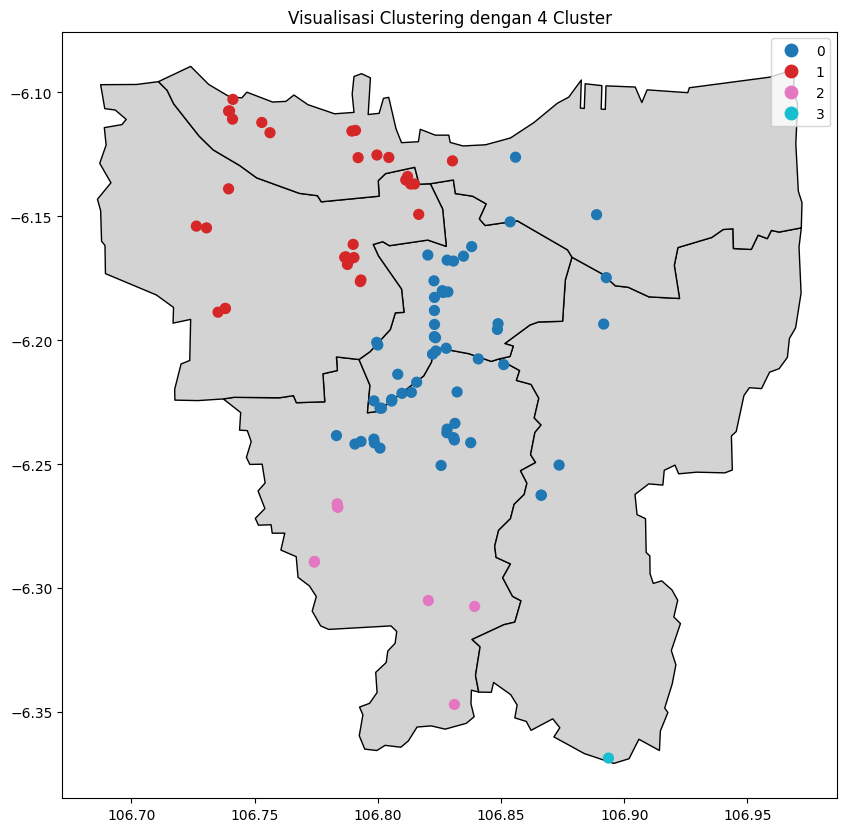

In [19]:
fig, ax = plt.subplots()
jakarta_map.plot(ax=ax, color="lightgrey", edgecolor='black')
halte_gdf.plot(ax=ax, column='Cluster_4', categorical=True, legend=True, markersize=50)
ax.set_title("Visualisasi Clustering dengan 4 Cluster")
plt.show()


5c. Berdasarkan hasil clustering yang Anda lakukan pada poin 5b, terdapat 4 kelompok halte yang terbentuk berdasarkan kedekatan geografisnya. Sebutkan dan jelaskan masing-masing cluster yang terbentuk beserta area yang dicakupnya! (5)

Berdasarkan hasil clustering dengan Agglomerative Clustering (4 cluster) yang menggunakan jarak Haversine, kita dapat mengidentifikasi empat kelompok halte dengan pola sebaran geografis yang berbeda. Berikut adalah deskripsi masing-masing cluster:

- **Cluster 0:**  
  Merupakan cluster terbesar yang mencakup halte-haltes di pusat kota dan sebagian wilayah selatan Jakarta. Halte seperti *Blok M*, *Bundaran Senayan*, *Gelora Bung Karno*, *Polda Metro Jaya*, dan *MH Thamrin* termasuk di dalamnya. Area ini umumnya merupakan pusat aktivitas bisnis, komersial, dan pemerintahan, sehingga tingkat mobilitas dan kepadatan pengguna Transjakarta di kawasan ini sangat tinggi.

- **Cluster 1:**  
  Cluster ini mengelompokkan halte-haltes yang tersebar di wilayah barat dan utara Jakarta, seperti beberapa halte di daerah urban yang memiliki kepadatan tinggi namun dengan pola sebaran yang berbeda dibandingkan cluster 0. Contoh halte pada cluster ini antara lain *Olimo*, *Kota*, dan halte-haltes lain yang menunjukkan adanya perbedaan dalam aksesibilitas atau fungsi pendukung transportasi di area tersebut.

- **Cluster 2:**  
  Kelompok ini mencakup halte yang terletak di area selatan Jakarta atau di perbatasan antara pusat kota dan pinggiran. Halte seperti *Ragunan*, *Lebak Bulus*, dan *Pondok Indah* termasuk dalam cluster ini. Pola distribusinya menunjukkan area dengan kepadatan yang lebih tersebar, mencerminkan karakteristik daerah yang mungkin memiliki campuran fungsi residensial dan komersial.

- **Cluster 3:**  
  Merupakan cluster dengan jumlah halte yang relatif sedikit, contohnya *Cibubur Junction*. Cluster ini menunjukkan adanya area yang terletak jauh dari inti kota atau di pinggiran, yang kemungkinan memiliki tingkat mobilitas yang berbeda dan bisa jadi merupakan target pasar khusus bagi strategi pengembangan gerai atau layanan tambahan.

Secara keseluruhan, setiap cluster memberikan gambaran tentang karakteristik geografis dan fungsi aktivitas transportasi di Jakarta, sehingga informasi ini dapat digunakan untuk penentuan strategi lokasi, misalnya dalam penentuan lokasi gerai minimarket yang menargetkan pengguna Transjakarta sesuai dengan pola mobilitas dan kepadatan tiap kawasan.

5d. Lakukan pengelompokan untuk zonasi wilayah dari halte yang sering dikunjungi. Gunakan algoritma Agglomerative Clustering dengan jumlah cluster = 6 dan meggunakan jarak Haversine. Kemudian tampilkan Nama Halte, Rute, Tipe, Lokasi, Lat, Long, In, Out, Transit, Geometry, dan Cluster dalam bentuk dataframe. (10)

Hint:
- Gunakan average linkage,
- Data yang digunakan untuk clustering adalah data lengkap saat pertama kali Anda load dataset "Data Lokasi Halte.xlsx"
- Gunakan fitur **Lat** dan **Long** untuk clustering.

In [30]:
# Lakukan clustering dengan 6 cluster
clustering6 = AgglomerativeClustering(n_clusters=6, metric='precomputed', linkage='average')
labels6 = clustering6.fit_predict(dist_matrix)
halte_gdf['Cluster_6'] = labels6


# Tampilkan beberapa data dengan cluster 6
cols_to_show_6 = ['Nama Halte', 'Rute', 'Tipe', 'Lokasi', 'Lat', 'Long', 'In', 'Out', 'Transit', 'geometry', 'Cluster_6']
print("Hasil Clustering (6 Cluster):")
halte_gdf[cols_to_show_6]


Hasil Clustering (6 Cluster):


,Nama Halte,Rute,Tipe,Lokasi,Lat,Long,In,Out,Transit,geometry,Cluster_6
0,Blok M,1,Halte,Jakarta Selatan,-6.243500,106.800900,1,1,1,POINT (106.8009 -6.2435),4
1,CSW,1,Halte,Jakarta Selatan,-6.239874,106.798413,1,1,1,POINT (106.79841 -6.23987),4
2,Bundaran Senayan,1,Halte,Jakarta Selatan,-6.227400,106.801500,1,1,1,POINT (106.8015 -6.2274),4
3,Gelora Bung Karno,1,Halte,Jakarta Selatan,-6.224200,106.805700,1,1,1,POINT (106.8057 -6.2242),4
4,Polda Metro Jaya,1,Halte,Jakarta Selatan,-6.221400,106.809800,0,1,0,POINT (106.8098 -6.2214),4
5,Dukuh Atas,1,Halte,Jakarta Selatan,-6.205600,106.822200,1,0,1,POINT (106.8222 -6.2056),4
6,Tosari,1,Halte,Jakarta Pusat,-6.198600,106.823000,1,1,1,POINT (106.823 -6.1986),4
7,Bundaran HI,1,Halte,Jakarta Pusat,-6.193605,106.823016,0,1,0,POINT (106.82302 -6.1936),4
8,MH Thamrin,1,Halte,Jakarta Pusat,-6.187970,106.822970,1,1,1,POINT (106.82297 -6.18797),4
9,Monas,1,Halte,Jakarta Pusat,-6.176000,106.822800,0,1,1,POINT (106.8228 -6.176),4


5e. Visualisasikan peta dan titik hasil clustering dengan peta Daerah Khusus Jakarta, bedakan warna titik berdasarkan cluster (untuk 6 cluster). (10)

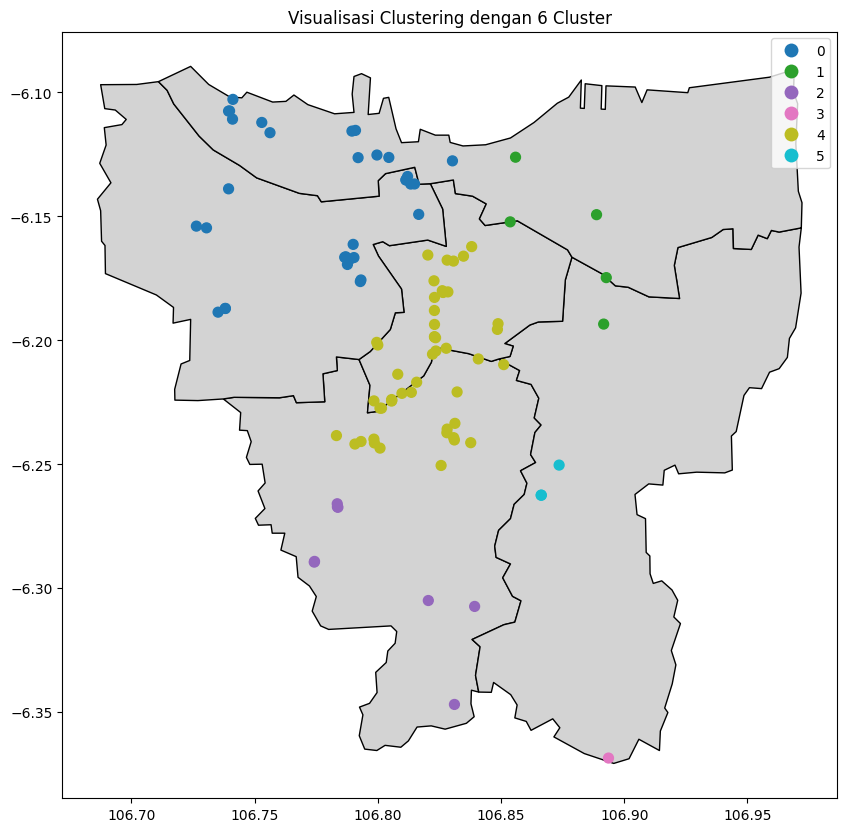

In [31]:
fig, ax = plt.subplots()
jakarta_map.plot(ax=ax, color="lightgrey", edgecolor='black')
halte_gdf.plot(ax=ax, column='Cluster_6', categorical=True, legend=True, markersize=50)
ax.set_title("Visualisasi Clustering dengan 6 Cluster")
plt.show()


5f. Berdasarkan hasil clustering yang Anda lakukan pada poin 5e, terdapat 6 kelompok halte yang terbentuk berdasarkan kedekatan geografisnya. Sebutkan dan jelaskan masing-masing cluster yang terbentuk beserta area yang dicakupnya! (5)

Berdasarkan hasil clustering dengan 6 kelompok, berikut adalah interpretasi dan deskripsi masing-masing cluster beserta area yang dicakupnya. Perlu diingat bahwa penentuan area dilakukan dengan mengamati sebaran titik halte dan konteks geografis Jakarta dari hasil clustering:

- **Cluster 0:**  
  Kelompok ini cenderung mencakup halte-haltes di wilayah Jakarta Utara dan beberapa bagian pinggiran Jakarta Barat. Area ini umumnya memiliki persebaran titik yang lebih tersebar, dengan beberapa halte yang berada di daerah residensial serta area komersial kecil. Cluster 0 bisa dijadikan indikasi sebagai kawasan dengan kepadatan transportasi sedang di wilayah utara/pinggiran barat.

- **Cluster 1:**  
  Cluster ini mengelompokkan halte yang terletak di area tertentu di Jakarta Utara. Biasanya, titik-titik di cluster 1 berada pada kawasan dengan fungsi kegiatan komersial dan juga sebagai titik penghubung antar moda, sehingga menunjukkan konsentrasi pengguna yang cukup tinggi meskipun secara geografis tidak sedekat cluster lain.

- **Cluster 2:**  
  Kelompok ini umumnya terdiri atas halte-haltes yang terletak di wilayah Jakarta Selatan. Area ini cenderung padat dengan aktivitas, baik komersial maupun residensial, dan memiliki pergerakan orang yang tinggi. Halte di cluster 2 sering kali menjadi titik strategis di pusat-pusat aktivitas di Jakarta Selatan.

- **Cluster 3:**  
  Cluster 3 mengelompokkan beberapa halte yang berada di area Jakarta Timur atau di perbatasan antara Jakarta Timur dan wilayah lain. Titik-titik di sini bisa merepresentasikan area dengan dinamika mobilitas yang berbeda, misalnya lebih banyak aktivitas transit atau pergerakan yang menghubungkan pusat kota dengan daerah pinggiran.

- **Cluster 4:**  
  Kelompok terbesar (berdasarkan hasil yang muncul pada banyak halte seperti Blok M, Bundaran Senayan, Gelora Bung Karno, dan sekitarnya) ini mencakup area inti atau pusat kota, terutama Jakarta Pusat dan sekitarnya. Cluster 4 mewakili wilayah dengan tingkat kepadatan tinggi, aktivitas ekonomi yang padat, dan pergerakan penumpang yang signifikan—karakteristik khas dari pusat kota Jakarta.

- **Cluster 5:**  
  Cluster ini cenderung terdiri dari halte-haltes yang terletak di area dengan karakteristik khusus, misalnya di wilayah yang lebih dekat ke titik-titik penghubung utama antar moda atau di area dengan fungsi transportasi tertentu (misalnya halte yang berdekatan dengan terminal atau kawasan transit besar). Area ini mungkin tidak sebanyak atau tidak sepadat area inti, namun penting sebagai simpul penghubung.

Interpretasi di atas didasarkan pada hasil clustering yang diperoleh dari perhitungan jarak Haversine dan metode linkage average. Setiap cluster menunjukkan pola geografis yang dapat digunakan untuk analisis lebih lanjut, misalnya dalam menentukan lokasi gerai atau strategi pengembangan transportasi yang sesuai dengan karakteristik masing-masing kawasan.